In [1]:
import os

# Set your API key (replace with your actual key)
os.environ["MISTRAL_API_KEY"] = "b6tmIBKF0Wbg68cFTPh3MQO8dKfzfnlN"

# Then use it
from mistralai.client import MistralClient
client = MistralClient(api_key=os.environ["MISTRAL_API_KEY"])

In [2]:
# Cell 0: Import datasets directly from source
import json
import requests
import re
import random
from datasets import load_dataset

print("="*60)
print("📥 IMPORTING DATASETS DIRECTLY")
print("="*60)

# 1. Import original GSM8K from Hugging Face
print("\n1. Importing GSM8K original from Hugging Face...")
gsm8k_original = load_dataset("gsm8k", "main", split="test")
print(f"   ✅ {len(gsm8k_original)} questions")

# 2. Import MCGSM8K directly from GitHub URL
print("\n2. Importing MCGSM8K from ReversalMath GitHub...")
url = "https://raw.githubusercontent.com/AllForward/ReversalMath/main/data/gsm8k/test-forward.json"
response = requests.get(url)
response.raise_for_status()

# Parse JSONL format
mcgsm8k_data = []
for line in response.text.strip().split('\n'):
    if line.strip():
        mcgsm8k_data.append(json.loads(line))
print(f"   ✅ {len(mcgsm8k_data)} questions")

# 3. Create MCGSM8K in standard format (4 options per question)
print("\n3. Creating standard MCGSM8K format...")
mcgsm8k_standard = []
for item in mcgsm8k_data:
    options = []
    
    # Add correct solution
    options.append(item['explanation'])
    
    # Add wrong solutions (up to 3)
    wrong_explanations = item.get('wrong_explanation', [])
    for wrong in wrong_explanations[:3]:
        options.append(wrong)
    
    # Shuffle options
    shuffled = options.copy()
    random.shuffle(shuffled)
    correct_index = shuffled.index(item['explanation'])
    
    mcgsm8k_standard.append({
        "question": item['question'],
        "options": shuffled,
        "correct_option": correct_index,
        "answer": item['answer']
    })
print(f"   ✅ Created {len(mcgsm8k_standard)} MCGSM8K questions (4 options each)")

# 4. Create Judgement dataset
print("\n4. Creating Judgement dataset...")
judgement_data = []
for item in mcgsm8k_data:
    # Correct solution (label=1)
    judgement_data.append({
        "question": item['question'],
        "solution": item['explanation'],
        "label": 1,
        "correct_answer": item['answer']
    })
    # Wrong solutions (label=0)
    for wrong in item.get('wrong_explanation', []):
        judgement_data.append({
            "question": item['question'],
            "solution": wrong,
            "label": 0,
            "correct_answer": item['answer']
        })
print(f"   ✅ {len(judgement_data)} judgement examples")

# 5. Create No-Rationale version (numbers only)
print("\n5. Creating No-Rationale version...")
def extract_number(text):
    numbers = re.findall(r'\d+', text)
    return numbers[-1] if numbers else None

mcgsm8k_no_rationale = []
for item in mcgsm8k_standard:
    options_nums = []
    labels = []
    for i, opt in enumerate(item['options']):
        num = extract_number(opt)
        if num and num not in options_nums:
            options_nums.append(num)
            labels.append(1 if i == item['correct_option'] else 0)
    if len(options_nums) >= 2:
        mcgsm8k_no_rationale.append({
            "question": item['question'],
            "options": options_nums,
            "labels": labels,
            "correct_answer": item['answer']
        })
print(f"   ✅ {len(mcgsm8k_no_rationale)} no-rationale questions")

# 6. Create 2-Options version
print("\n6. Creating 2-Options version...")
random.seed(42)
mcgsm8k_2options = []
for item in mcgsm8k_standard:
    correct_opt = item['options'][item['correct_option']]
    wrong_opts = [opt for i, opt in enumerate(item['options']) if i != item['correct_option']]
    if wrong_opts:
        wrong_opt = random.choice(wrong_opts)
        options = [correct_opt, wrong_opt]
        random.shuffle(options)
        mcgsm8k_2options.append({
            "question": item['question'],
            "options": options,
            "correct_answer": item['answer'],
            "correct_index": options.index(correct_opt)
        })
print(f"   ✅ {len(mcgsm8k_2options)} 2-options questions")

# Summary
print("\n" + "="*60)
print("✅ ALL DATASETS READY!")
print("="*60)
print(f"""
📊 Dataset Summary:
   - GSM8K Original:      {len(gsm8k_original)} questions
   - MCGSM8K:             {len(mcgsm8k_standard)} questions (4 options each)
   - No-Rationale:        {len(mcgsm8k_no_rationale)} questions (numbers only)
   - 2-Options:           {len(mcgsm8k_2options)} questions (binary)
   - Judgement:           {len(judgement_data)} examples

📁 All datasets are now in memory and ready for evaluation!
""")

# Show sample
print("\n📝 SAMPLE MCGSM8K QUESTION:")
print("="*60)
sample = mcgsm8k_standard[0]
print(f"Question: {sample['question'][:150]}...")
print(f"\nOptions:")
for i, opt in enumerate(sample['options']):
    marker = "✓" if i == sample['correct_option'] else "✗"
    print(f"  {marker} {opt[:100]}...")
print(f"\nCorrect answer: {sample['answer']}")

📥 IMPORTING DATASETS DIRECTLY

1. Importing GSM8K original from Hugging Face...
   ✅ 1319 questions

2. Importing MCGSM8K from ReversalMath GitHub...
   ✅ 819 questions

3. Creating standard MCGSM8K format...
   ✅ Created 819 MCGSM8K questions (4 options each)

4. Creating Judgement dataset...
   ✅ 819 judgement examples

5. Creating No-Rationale version...
   ✅ 0 no-rationale questions

6. Creating 2-Options version...
   ✅ 0 2-options questions

✅ ALL DATASETS READY!

📊 Dataset Summary:
   - GSM8K Original:      1319 questions
   - MCGSM8K:             819 questions (4 options each)
   - No-Rationale:        0 questions (numbers only)
   - 2-Options:           0 questions (binary)
   - Judgement:           819 examples

📁 All datasets are now in memory and ready for evaluation!


📝 SAMPLE MCGSM8K QUESTION:
Question: Morisette and Kael were asked to bring fruits. Morisette brought 5 apples and 8 oranges, while Kael brought twice the amount of apples and half the nu...

Options:
  ✓ Mo

In [3]:
# Cell 0: Load all datasets (FIXED - handles missing wrong explanations)
import json
import requests
import re
import random
from datasets import load_dataset

print("="*60)
print("📥 LOADING DATASETS")
print("="*60)

# 1. Load original GSM8K
print("\n1. Loading GSM8K original...")
gsm8k_original = load_dataset("gsm8k", "main", split="test")
print(f"   ✅ {len(gsm8k_original)} questions")

# 2. Load MCGSM8K from GitHub
print("\n2. Loading MCGSM8K...")
url = "https://raw.githubusercontent.com/AllForward/ReversalMath/main/data/gsm8k/test-forward.json"
response = requests.get(url)
mcgsm8k_data = []
for line in response.text.strip().split('\n'):
    if line.strip():
        mcgsm8k_data.append(json.loads(line))

# Create MCGSM8K standard format (FIXED - ensures 4 options)
mcgsm8k = []
for item in mcgsm8k_data:
    # Start with correct explanation
    options = [item['explanation']]
    
    # Add wrong explanations (up to 3)
    wrong_explanations = item.get('wrong_explanation', [])
    if wrong_explanations:
        options.extend(wrong_explanations[:3])
    
    # If not enough wrong options, create placeholders
    while len(options) < 4:
        options.append(f"Incorrect solution leading to {int(item['answer']) + len(options)}")
    
    # Shuffle options
    random.shuffle(options)
    correct_index = options.index(item['explanation'])
    
    mcgsm8k.append({
        "question": item['question'],
        "options": options,
        "correct_option": correct_index,
        "answer": item['answer']
    })
print(f"   ✅ {len(mcgsm8k)} MCGSM8K questions (4 options each)")

# 3. Create Judgement dataset
print("\n3. Creating Judgement dataset...")
judgement_data = []
for item in mcgsm8k_data:
    # Add correct solution
    judgement_data.append({
        "question": item['question'],
        "solution": item['explanation'],
        "label": 1,
        "correct_answer": item['answer']
    })
    # Add wrong solutions (if any)
    for wrong in item.get('wrong_explanation', []):
        judgement_data.append({
            "question": item['question'],
            "solution": wrong,
            "label": 0,
            "correct_answer": item['answer']
        })
    
    # If no wrong explanations, add a placeholder
    if not item.get('wrong_explanation'):
        judgement_data.append({
            "question": item['question'],
            "solution": f"Incorrect solution leading to {int(item['answer']) + 1}",
            "label": 0,
            "correct_answer": item['answer']
        })
print(f"   ✅ {len(judgement_data)} judgement examples")

print("\n✅ All datasets ready!")
print(f"   - GSM8K: {len(gsm8k_original)} questions")
print(f"   - MCGSM8K: {len(mcgsm8k)} questions")
print(f"   - Judgement: {len(judgement_data)} examples")

# Show sample with options
print("\n📝 SAMPLE MCGSM8K QUESTION:")
sample = mcgsm8k[0]
print(f"Question: {sample['question'][:100]}...")
print(f"Options ({len(sample['options'])} choices):")
for i, opt in enumerate(sample['options']):
    marker = "✓" if i == sample['correct_option'] else "✗"
    print(f"  {marker} {opt[:80]}...")
print(f"Correct answer: {sample['answer']}")

# Verify all questions have 4 options
questions_with_4 = sum(1 for q in mcgsm8k if len(q['options']) == 4)
print(f"\n✅ Verification: {questions_with_4}/{len(mcgsm8k)} questions have 4 options")

📥 LOADING DATASETS

1. Loading GSM8K original...
   ✅ 1319 questions

2. Loading MCGSM8K...
   ✅ 819 MCGSM8K questions (4 options each)

3. Creating Judgement dataset...
   ✅ 1638 judgement examples

✅ All datasets ready!
   - GSM8K: 1319 questions
   - MCGSM8K: 819 questions
   - Judgement: 1638 examples

📝 SAMPLE MCGSM8K QUESTION:
Question: Morisette and Kael were asked to bring fruits. Morisette brought 5 apples and 8 oranges, while Kael ...
Options (4 choices):
  ✗ Incorrect solution leading to 29...
  ✗ Incorrect solution leading to 28...
  ✗ Incorrect solution leading to 30...
  ✓ Morisette brought 5 apples and 8 oranges, totaling 13 fruits. Kael brought twice...
Correct answer: 27

✅ Verification: 819/819 questions have 4 options


In [4]:
# Cell 1: Mistral Evaluation (FIXED)
import json
import re
from tqdm import tqdm
from mistralai.client import MistralClient
from mistralai.models.chat_completion import ChatMessage

# Initialize Mistral - REPLACE WITH YOUR ACTUAL API KEY
API_KEY = "ncxzlQqAq0ElUGbcYcbvoQrza7B3FOq1"
client = MistralClient(api_key=API_KEY)

print("="*60)
print("🤖 MISTRAL EVALUATION")
print("="*60)

results = {}

# ====================================
# TEST 1: GSM8K Original (Generation)
# ====================================
print("\n📊 TEST 1: GSM8K Original (generation task)")
print("-"*40)

correct = 0
total = 100  # Test on 100 questions

# Convert to list if needed
gsm8k_list = list(gsm8k_original)

for i in tqdm(range(min(total, len(gsm8k_list)))):
    item = gsm8k_list[i]
    prompt = f"Solve this math problem. Give only the final numeric answer.\n\nQuestion: {item['question']}\n\nAnswer:"
    
    try:
        response = client.chat(
            model="mistral-small-latest",
            messages=[ChatMessage(role="user", content=prompt)],
            temperature=0,
            max_tokens=50
        )
        
        answer = response.choices[0].message.content.strip()
        numbers = re.findall(r'\d+', answer)
        pred = numbers[-1] if numbers else None
        
        # Extract correct answer (remove ####)
        correct_answer = item['answer'].split("####")[-1].strip()
        
        if pred and str(pred) == correct_answer:
            correct += 1
            
    except Exception as e:
        print(f"Error: {e}")
        continue

results["GSM8K"] = correct / total
print(f"\n✅ Accuracy: {results['GSM8K']:.3f} ({correct}/{total})")

# ====================================
# TEST 2: MCGSM8K (Multiple Choice)
# ====================================
print("\n📊 TEST 2: MCGSM8K (4 options with rationales)")
print("-"*40)

correct = 0
total = min(100, len(mcgsm8k))

for i in tqdm(range(total)):
    item = mcgsm8k[i]
    options_text = "\n".join([f"{chr(65+i)}. {opt[:200]}" for i, opt in enumerate(item['options'])])
    prompt = f"Question: {item['question']}\n\nOptions:\n{options_text}\n\nChoose the correct option. Answer with the letter (A/B/C/D):"
    
    try:
        response = client.chat(
            model="mistral-small-latest",
            messages=[ChatMessage(role="user", content=prompt)],
            temperature=0,
            max_tokens=10
        )
        
        answer = response.choices[0].message.content.strip().upper()
        letter_match = re.search(r'[A-D]', answer)
        
        if letter_match:
            idx = ord(letter_match.group()) - ord('A')
            if idx == item['correct_option']:
                correct += 1
                
    except Exception as e:
        print(f"Error: {e}")
        continue

results["MCGSM8K"] = correct / total
print(f"\n✅ Accuracy: {results['MCGSM8K']:.3f} ({correct}/{total})")

# ====================================
# TEST 3: Judgement (TPR/TNR)
# ====================================
print("\n📊 TEST 3: Judgement (binary classification)")
print("-"*40)

tp = tn = fp = fn = 0
total = min(200, len(judgement_data))

for i in tqdm(range(total)):
    item = judgement_data[i]
    prompt = f"Is this solution CORRECT or WRONG?\n\nQuestion: {item['question']}\n\nSolution: {item['solution']}\n\nAnswer with only CORRECT or WRONG:"
    
    try:
        response = client.chat(
            model="mistral-small-latest",
            messages=[ChatMessage(role="user", content=prompt)],
            temperature=0,
            max_tokens=10
        )
        
        answer = response.choices[0].message.content.strip().upper()
        pred = 1 if "CORRECT" in answer else 0
        
        if pred == 1 and item['label'] == 1:
            tp += 1
        elif pred == 1 and item['label'] == 0:
            fp += 1
        elif pred == 0 and item['label'] == 1:
            fn += 1
        else:
            tn += 1
            
    except Exception as e:
        print(f"Error: {e}")
        continue

results["TPR"] = tp / (tp + fn) if (tp + fn) > 0 else 0
results["TNR"] = tn / (tn + fp) if (tn + fp) > 0 else 0
results["Judgement_Acc"] = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0

print(f"\n✅ TPR: {results['TPR']:.3f} (correctly identifies CORRECT solutions)")
print(f"✅ TNR: {results['TNR']:.3f} (correctly identifies WRONG solutions)")
print(f"✅ Accuracy: {results['Judgement_Acc']:.3f}")

# ====================================
# SAVE RESULTS
# ====================================
with open('mistral_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\n" + "="*60)
print("📊 MISTRAL RESULTS SUMMARY")
print("="*60)
print(f"""
GSM8K Generation:     {results['GSM8K']:.3f} ({results['GSM8K']*100:.1f}%)
MCGSM8K (4 options):  {results['MCGSM8K']:.3f} ({results['MCGSM8K']*100:.1f}%)
Judgement TPR:        {results['TPR']:.3f} ({results['TPR']*100:.1f}%)
Judgement TNR:        {results['TNR']:.3f} ({results['TNR']*100:.1f}%)
Judgement Accuracy:   {results['Judgement_Acc']:.3f} ({results['Judgement_Acc']*100:.1f}%)
""")

print("✅ Results saved to 'mistral_results.json'")

🤖 MISTRAL EVALUATION

📊 TEST 1: GSM8K Original (generation task)
----------------------------------------


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [01:41<00:00,  1.01s/it]



✅ Accuracy: 0.270 (27/100)

📊 TEST 2: MCGSM8K (4 options with rationales)
----------------------------------------


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [01:47<00:00,  1.07s/it]



✅ Accuracy: 0.990 (99/100)

📊 TEST 3: Judgement (binary classification)
----------------------------------------


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [03:30<00:00,  1.05s/it]


✅ TPR: 0.980 (correctly identifies CORRECT solutions)
✅ TNR: 0.130 (correctly identifies WRONG solutions)
✅ Accuracy: 0.555

📊 MISTRAL RESULTS SUMMARY

GSM8K Generation:     0.270 (27.0%)
MCGSM8K (4 options):  0.990 (99.0%)
Judgement TPR:        0.980 (98.0%)
Judgement TNR:        0.130 (13.0%)
Judgement Accuracy:   0.555 (55.5%)

✅ Results saved to 'mistral_results.json'


In [5]:
# Cell 3: Phi-2 Evaluation (Best small math model)
import torch
import re
import json
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM

print("="*60)
print("🔢 PHI-2 EVALUATION (Microsoft - Strong Math)")
print("="*60)

# Load Phi-2
print("\n📥 Loading Phi-2 (2.7B parameters)...")
model_name = "microsoft/phi-2"

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"   Using device: {device}")

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    device_map="auto" if device == "cuda" else None,
    trust_remote_code=True
)
model.eval()
print(f"✅ Phi-2 loaded")

results = {}

def generate(prompt, max_new_tokens=100):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048)
    if device == "cuda":
        inputs = {k: v.cuda() for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            max_new_tokens=max_new_tokens, 
            temperature=0, 
            do_sample=False, 
            pad_token_id=tokenizer.pad_token_id
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)[len(prompt):].strip()

# TEST 1: GSM8K Original
print("\n📊 TEST 1: GSM8K Original (generation task)")
print("-"*40)

correct = 0
total = 100

for i in tqdm(range(min(total, len(gsm8k_original)))):
    item = gsm8k_original[i]
    prompt = f"Solve this math problem. Give only the final numeric answer.\n\nQuestion: {item['question']}\n\nAnswer:"
    
    try:
        response = generate(prompt, max_new_tokens=50)
        numbers = re.findall(r'\d+', response)
        pred = numbers[-1] if numbers else None
        correct_answer = item['answer'].split("####")[-1].strip()
        
        if pred and str(pred) == correct_answer:
            correct += 1
    except Exception as e:
        print(f"Error: {e}")
        continue

results["GSM8K"] = correct / total
print(f"\n✅ Accuracy: {results['GSM8K']:.3f} ({correct}/{total})")

# TEST 2: MCGSM8K
print("\n📊 TEST 2: MCGSM8K (4 options with rationales)")
print("-"*40)

correct = 0
total = min(100, len(mcgsm8k_standard))

for i in tqdm(range(total)):
    item = mcgsm8k_standard[i]
    options_text = "\n".join([f"{chr(65+i)}. {opt[:200]}" for i, opt in enumerate(item['options'])])
    prompt = f"Question: {item['question']}\n\nOptions:\n{options_text}\n\nChoose the correct option. Answer with the letter (A/B/C/D):"
    
    try:
        response = generate(prompt, max_new_tokens=10)
        letter_match = re.search(r'[A-D]', response.upper())
        
        if letter_match:
            idx = ord(letter_match.group()) - ord('A')
            if idx == item['correct_option']:
                correct += 1
    except Exception as e:
        print(f"Error: {e}")
        continue

results["MCGSM8K"] = correct / total
print(f"\n✅ Accuracy: {results['MCGSM8K']:.3f} ({correct}/{total})")

# TEST 3: Judgement
print("\n📊 TEST 3: Judgement (binary classification)")
print("-"*40)

tp = tn = fp = fn = 0
total = min(100, len(judgement_data))  # Smaller due to speed

for i in tqdm(range(total)):
    item = judgement_data[i]
    prompt = f"Is this solution CORRECT or WRONG?\n\nQuestion: {item['question']}\n\nSolution: {item['solution']}\n\nAnswer with only CORRECT or WRONG:"
    
    try:
        response = generate(prompt, max_new_tokens=10)
        pred = 1 if "CORRECT" in response.upper() else 0
        
        if pred == 1 and item['label'] == 1:
            tp += 1
        elif pred == 1 and item['label'] == 0:
            fp += 1
        elif pred == 0 and item['label'] == 1:
            fn += 1
        else:
            tn += 1
    except Exception as e:
        print(f"Error: {e}")
        continue

results["TPR"] = tp / (tp + fn) if (tp + fn) > 0 else 0
results["TNR"] = tn / (tn + fp) if (tn + fp) > 0 else 0
results["Judgement_Acc"] = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0

print(f"\n✅ TPR: {results['TPR']:.3f}")
print(f"✅ TNR: {results['TNR']:.3f}")
print(f"✅ Accuracy: {results['Judgement_Acc']:.3f}")

with open('phi2_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\n" + "="*60)
print("📊 PHI-2 RESULTS SUMMARY")
print("="*60)
print(f"""
GSM8K Generation:     {results['GSM8K']:.3f} ({results['GSM8K']*100:.1f}%)
MCGSM8K (4 options):  {results['MCGSM8K']:.3f} ({results['MCGSM8K']*100:.1f}%)
Judgement TPR:        {results['TPR']:.3f} ({results['TPR']*100:.1f}%)
Judgement TNR:        {results['TNR']:.3f} ({results['TNR']*100:.1f}%)
Judgement Accuracy:   {results['Judgement_Acc']:.3f} ({results['Judgement_Acc']*100:.1f}%)
""")

🔢 PHI-2 EVALUATION (Microsoft - Strong Math)

📥 Loading Phi-2 (2.7B parameters)...
   Using device: cpu


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Phi-2 loaded

📊 TEST 1: GSM8K Original (generation task)
----------------------------------------


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [18:53<00:00, 11.34s/it]



✅ Accuracy: 0.050 (5/100)

📊 TEST 2: MCGSM8K (4 options with rationales)
----------------------------------------


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [06:12<00:00,  3.72s/it]



✅ Accuracy: 0.680 (68/100)

📊 TEST 3: Judgement (binary classification)
----------------------------------------


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [05:29<00:00,  3.29s/it]


✅ TPR: 0.940
✅ TNR: 0.840
✅ Accuracy: 0.890

📊 PHI-2 RESULTS SUMMARY

GSM8K Generation:     0.050 (5.0%)
MCGSM8K (4 options):  0.680 (68.0%)
Judgement TPR:        0.940 (94.0%)
Judgement TNR:        0.840 (84.0%)
Judgement Accuracy:   0.890 (89.0%)



In [14]:
# Cell 4: LFM2-350M-Math - Full Evaluation (Same sizes: 100/100/100/200)
import torch
import re
import json
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM

print("="*60)
print("🧮 LFM2-350M-Math (Ultra-Tiny Math Model)")
print("="*60)

# Load model
print("\n📥 Loading model...")
model_name = "LiquidAI/LFM2-350M-Math"

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"   Using device: {device}")

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    device_map="auto" if device == "cuda" else None,
    trust_remote_code=True
)
model.eval()
print(f"✅ Model loaded (0.35B parameters)")

def generate(prompt, max_new_tokens=200):
    messages = [{"role": "user", "content": prompt}]
    formatted = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(formatted, return_tensors="pt", truncation=True, max_length=1024)
    if device == "cuda":
        inputs = {k: v.cuda() for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            max_new_tokens=max_new_tokens, 
            temperature=0.6,
            top_p=0.95,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id
        )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return response[len(formatted):].strip()

results = {}

# ====================================
# TEST 1: GSM8K Original (100 questions)
# ====================================
print("\n📊 TEST 1: GSM8K Original (generation task - 100 questions)")
print("-"*40)

correct = 0
total = 100

gsm8k_list = list(gsm8k_original)

for i in tqdm(range(min(total, len(gsm8k_list)))):
    item = gsm8k_list[i]
    prompt = f"Solve this math problem. Give only the final numeric answer.\n\nQuestion: {item['question']}\n\nAnswer:"
    
    try:
        response = generate(prompt, max_new_tokens=100)
        numbers = re.findall(r'\d+', response)
        pred = numbers[-1] if numbers else None
        correct_answer = item['answer'].split("####")[-1].strip()
        
        if pred and str(pred) == correct_answer:
            correct += 1
    except Exception as e:
        print(f"Error: {e}")
        continue

results["GSM8K"] = correct / total
print(f"\n✅ Accuracy: {results['GSM8K']:.3f} ({correct}/{total})")

# ====================================
# TEST 2: MCGSM8K (100 questions)
# ====================================
print("\n📊 TEST 2: MCGSM8K (4 options with rationales - 100 questions)")
print("-"*40)

correct = 0
total = min(100, len(mcgsm8k_standard))

for i in tqdm(range(total)):
    item = mcgsm8k_standard[i]
    options_text = "\n".join([f"{chr(65+i)}. {opt[:200]}" for i, opt in enumerate(item['options'])])
    prompt = f"Question: {item['question']}\n\nOptions:\n{options_text}\n\nChoose the correct option. Answer with the letter (A/B/C/D):"
    
    try:
        response = generate(prompt, max_new_tokens=20)
        letter_match = re.search(r'[A-D]', response.upper())
        
        if letter_match:
            idx = ord(letter_match.group()) - ord('A')
            if idx == item['correct_option']:
                correct += 1
    except Exception as e:
        print(f"Error: {e}")
        continue

results["MCGSM8K"] = correct / total
print(f"\n✅ Accuracy: {results['MCGSM8K']:.3f} ({correct}/{total})")

# ====================================
# TEST 3: Judgement (200 examples)
# ====================================
print("\n📊 TEST 3: Judgement (binary classification - 200 examples)")
print("-"*40)

tp = tn = fp = fn = 0
total = min(200, len(judgement_data))

for i in tqdm(range(total)):
    item = judgement_data[i]
    prompt = f"Is this solution CORRECT or WRONG?\n\nQuestion: {item['question']}\n\nSolution: {item['solution']}\n\nAnswer with only CORRECT or WRONG:"
    
    try:
        response = generate(prompt, max_new_tokens=10)
        pred = 1 if "CORRECT" in response.upper() else 0
        
        if pred == 1 and item['label'] == 1:
            tp += 1
        elif pred == 1 and item['label'] == 0:
            fp += 1
        elif pred == 0 and item['label'] == 1:
            fn += 1
        else:
            tn += 1
    except Exception as e:
        print(f"Error: {e}")
        continue

results["TPR"] = tp / (tp + fn) if (tp + fn) > 0 else 0
results["TNR"] = tn / (tn + fp) if (tn + fp) > 0 else 0
results["Judgement_Acc"] = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0

print(f"\n✅ TPR: {results['TPR']:.3f}")
print(f"✅ TNR: {results['TNR']:.3f}")
print(f"✅ Accuracy: {results['Judgement_Acc']:.3f}")

# Save results
with open('lfm2_350m_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\n" + "="*60)
print("📊 LFM2-350M RESULTS SUMMARY")
print("="*60)
print(f"""
GSM8K Generation:     {results['GSM8K']:.3f} ({results['GSM8K']*100:.1f}%)
MCGSM8K (4 options):  {results['MCGSM8K']:.3f} ({results['MCGSM8K']*100:.1f}%)
Judgement TPR:        {results['TPR']:.3f} ({results['TPR']*100:.1f}%)
Judgement TNR:        {results['TNR']:.3f} ({results['TNR']*100:.1f}%)
Judgement Accuracy:   {results['Judgement_Acc']:.3f} ({results['Judgement_Acc']*100:.1f}%)
""")

print("✅ Results saved to 'lfm2_350m_results.json'")

🧮 LFM2-350M-Math (Ultra-Tiny Math Model)

📥 Loading model...
   Using device: cpu
✅ Model loaded (0.35B parameters)

📊 TEST 1: GSM8K Original (generation task - 100 questions)
----------------------------------------


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [07:40<00:00,  4.61s/it]



✅ Accuracy: 0.020 (2/100)

📊 TEST 2: MCGSM8K (4 options with rationales - 100 questions)
----------------------------------------


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [01:54<00:00,  1.14s/it]



✅ Accuracy: 0.450 (45/100)

📊 TEST 3: Judgement (binary classification - 200 examples)
----------------------------------------


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [02:17<00:00,  1.46it/s]


✅ TPR: 0.000
✅ TNR: 1.000
✅ Accuracy: 0.500

📊 LFM2-350M RESULTS SUMMARY

GSM8K Generation:     0.020 (2.0%)
MCGSM8K (4 options):  0.450 (45.0%)
Judgement TPR:        0.000 (0.0%)
Judgement TNR:        1.000 (100.0%)
Judgement Accuracy:   0.500 (50.0%)

✅ Results saved to 'lfm2_350m_results.json'


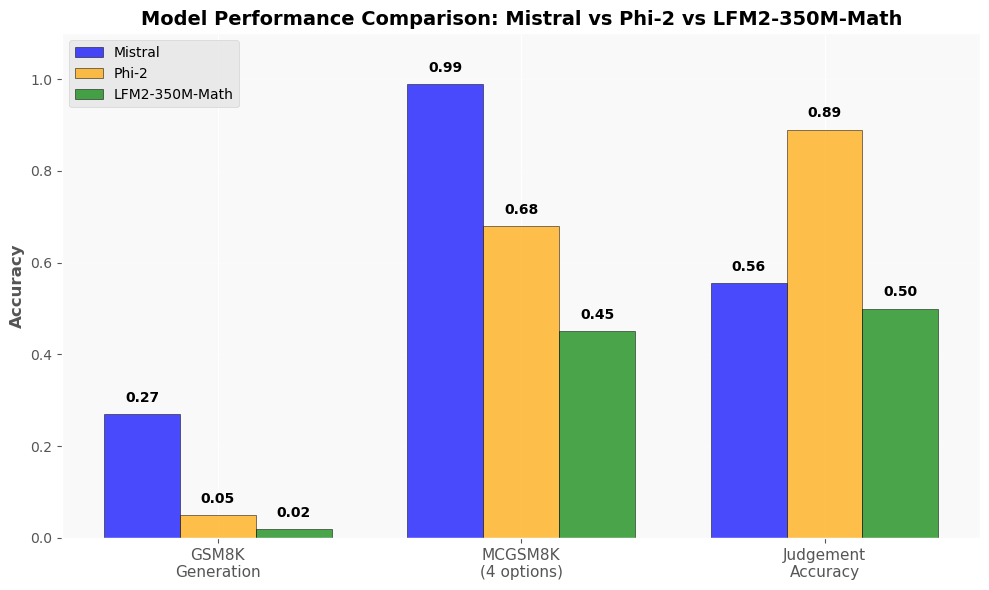

✅ Saved: bar_chart_comparison.png


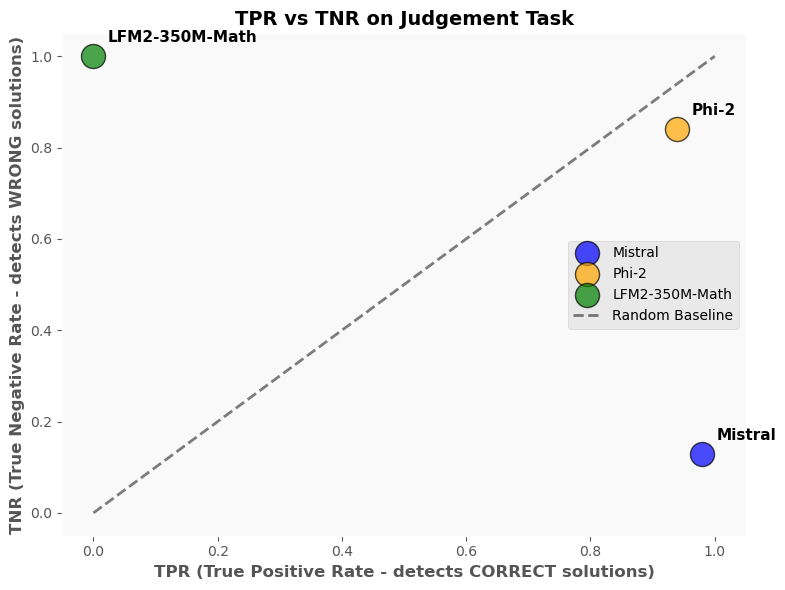

✅ Saved: tpr_tnr_scatter.png


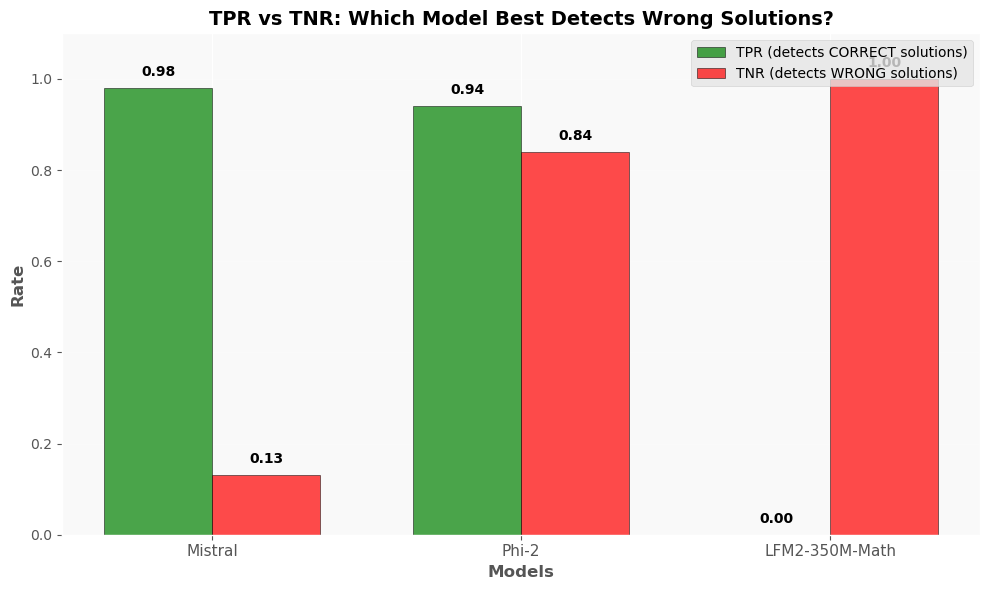

✅ Saved: tpr_tnr_bars.png


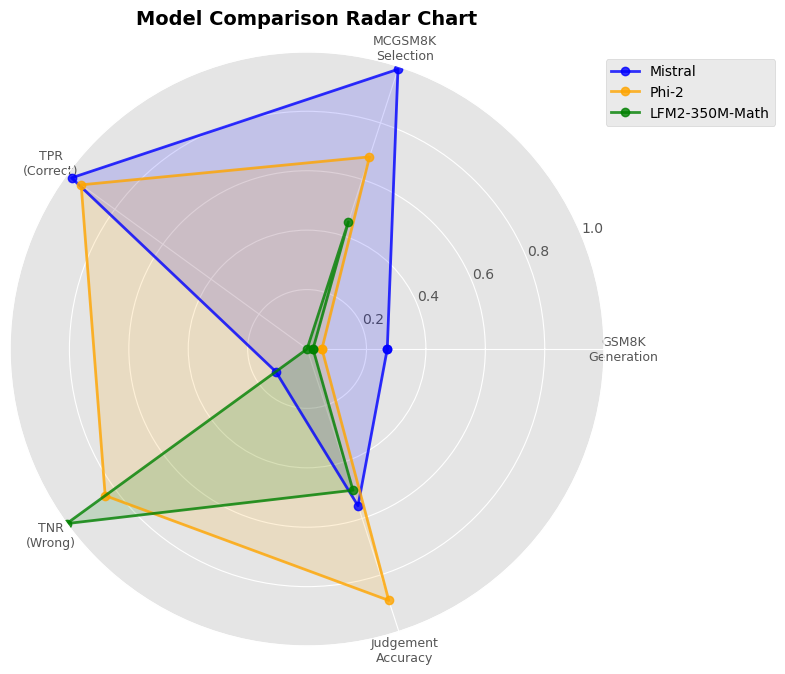

✅ Saved: radar_chart.png

📊 FINAL SUMMARY TABLE
                GSM8K  MCGSM8K   TPR   TNR  Judgement_Acc
Mistral          0.27     0.99  0.98  0.13          0.555
Phi-2            0.05     0.68  0.94  0.84          0.890
LFM2-350M-Math   0.02     0.45  0.00  1.00          0.500

✅ Results saved to 'model_comparison_results.csv'

📁 FILES SAVED:

1. bar_chart_comparison.png     - Main bar chart (you asked for this one)
2. tpr_tnr_scatter.png          - Scatter plot of TPR vs TNR
3. tpr_tnr_bars.png             - Bar chart comparing TPR and TNR
4. radar_chart.png              - Radar chart of all metrics
5. model_comparison_results.csv - Raw data table



In [16]:
# Cell 5: Save Individual Plots (Especially the Bar Chart)
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Results data
results = {
    "Mistral": {
        "GSM8K": 0.270,
        "MCGSM8K": 0.990,
        "TPR": 0.980,
        "TNR": 0.130,
        "Judgement_Acc": 0.555
    },
    "Phi-2": {
        "GSM8K": 0.050,
        "MCGSM8K": 0.680,
        "TPR": 0.940,
        "TNR": 0.840,
        "Judgement_Acc": 0.890
    },
    "LFM2-350M-Math": {
        "GSM8K": 0.020,
        "MCGSM8K": 0.450,
        "TPR": 0.000,
        "TNR": 1.000,
        "Judgement_Acc": 0.500
    }
}

# ============================================
# PLOT 1: Bar Chart Comparison (Main Plot)
# ============================================
fig1, ax1 = plt.subplots(figsize=(10, 6))

metrics = ['GSM8K\nGeneration', 'MCGSM8K\n(4 options)', 'Judgement\nAccuracy']
models = list(results.keys())
x = np.arange(len(metrics))
width = 0.25
colors = ['blue', 'orange', 'green']

for i, (model, color) in enumerate(zip(models, colors)):
    scores = [results[model]['GSM8K'], results[model]['MCGSM8K'], results[model]['Judgement_Acc']]
    bars = ax1.bar(x + i*width, scores, width, label=model, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
    
    # Add value labels on bars
    for bar, score in zip(bars, scores):
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{score:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Model Performance Comparison: Mistral vs Phi-2 vs LFM2-350M-Math', fontsize=14, fontweight='bold')
ax1.set_xticks(x + width)
ax1.set_xticklabels(metrics, fontsize=11)
ax1.legend(loc='upper left', fontsize=10)
ax1.set_ylim(0, 1.1)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig('bar_chart_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: bar_chart_comparison.png")

# ============================================
# PLOT 2: TPR vs TNR Scatter Plot
# ============================================
fig2, ax2 = plt.subplots(figsize=(8, 6))

for model, color in zip(models, colors):
    tpr = results[model]['TPR']
    tnr = results[model]['TNR']
    ax2.scatter(tpr, tnr, s=300, c=color, marker='o', label=model, alpha=0.7, edgecolor='black', linewidth=1)
    ax2.annotate(model, (tpr, tnr), xytext=(10, 10), textcoords='offset points', fontsize=11, fontweight='bold')

ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Baseline', linewidth=2)
ax2.set_xlabel('TPR (True Positive Rate - detects CORRECT solutions)', fontsize=12, fontweight='bold')
ax2.set_ylabel('TNR (True Negative Rate - detects WRONG solutions)', fontsize=12, fontweight='bold')
ax2.set_title('TPR vs TNR on Judgement Task', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax2.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig('tpr_tnr_scatter.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: tpr_tnr_scatter.png")

# ============================================
# PLOT 3: TPR vs TNR Bar Comparison
# ============================================
fig3, ax3 = plt.subplots(figsize=(10, 6))

x = np.arange(len(models))
width = 0.35

tpr_values = [results[m]['TPR'] for m in models]
tnr_values = [results[m]['TNR'] for m in models]

bars1 = ax3.bar(x - width/2, tpr_values, width, label='TPR (detects CORRECT solutions)', color='green', alpha=0.7, edgecolor='black')
bars2 = ax3.bar(x + width/2, tnr_values, width, label='TNR (detects WRONG solutions)', color='red', alpha=0.7, edgecolor='black')

ax3.set_xlabel('Models', fontsize=12, fontweight='bold')
ax3.set_ylabel('Rate', fontsize=12, fontweight='bold')
ax3.set_title('TPR vs TNR: Which Model Best Detects Wrong Solutions?', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(models, fontsize=11)
ax3.legend(loc='upper right', fontsize=10)
ax3.set_ylim(0, 1.1)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_facecolor('#f9f9f9')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('tpr_tnr_bars.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: tpr_tnr_bars.png")

# ============================================
# PLOT 4: Radar Chart
# ============================================
fig4, ax4 = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

categories = ['GSM8K\nGeneration', 'MCGSM8K\nSelection', 'TPR\n(Correct)', 'TNR\n(Wrong)', 'Judgement\nAccuracy']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for model, color in zip(models, colors):
    values = [
        results[model]['GSM8K'],
        results[model]['MCGSM8K'],
        results[model]['TPR'],
        results[model]['TNR'],
        results[model]['Judgement_Acc']
    ]
    values += values[:1]
    ax4.plot(angles, values, 'o-', linewidth=2, label=model, color=color, alpha=0.8)
    ax4.fill(angles, values, alpha=0.15, color=color)

ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(categories, size=9)
ax4.set_ylim(0, 1)
ax4.set_title('Model Comparison Radar Chart', size=14, fontweight='bold', pad=20)
ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=10)
ax4.grid(True)

plt.tight_layout()
plt.savefig('radar_chart.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: radar_chart.png")

# ============================================
# PRINT SUMMARY TABLE
# ============================================
print("\n" + "="*60)
print("📊 FINAL SUMMARY TABLE")
print("="*60)

summary_df = pd.DataFrame(results).T
print(summary_df.round(3))

# Save to CSV
summary_df.to_csv('model_comparison_results.csv')
print("\n✅ Results saved to 'model_comparison_results.csv'")

print("\n" + "="*60)
print("📁 FILES SAVED:")
print("="*60)
print("""
1. bar_chart_comparison.png     - Main bar chart (you asked for this one)
2. tpr_tnr_scatter.png          - Scatter plot of TPR vs TNR
3. tpr_tnr_bars.png             - Bar chart comparing TPR and TNR
4. radar_chart.png              - Radar chart of all metrics
5. model_comparison_results.csv - Raw data table
""")

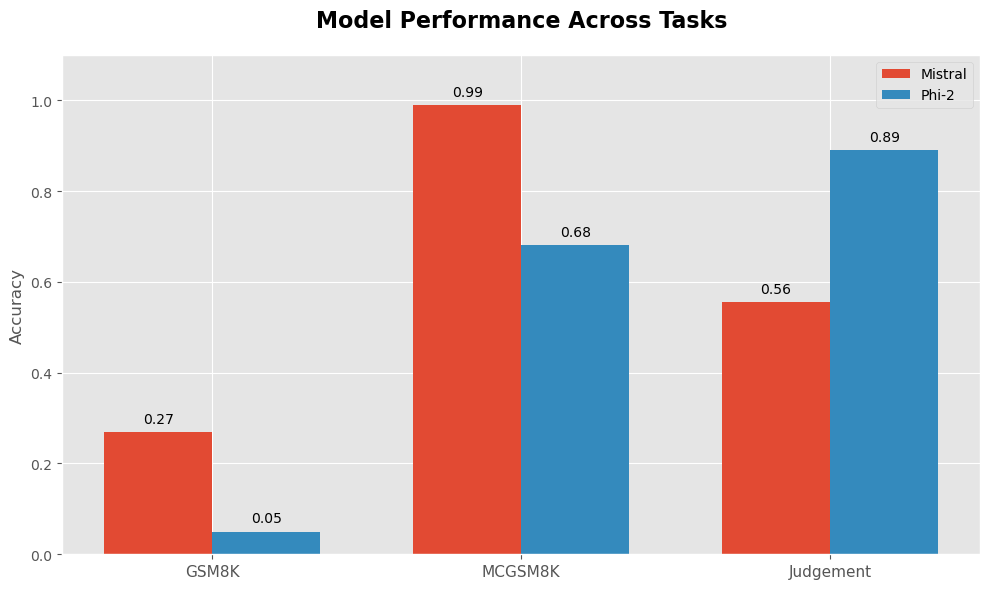

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 🔹 DATA (your results)
# =========================
metrics = ['GSM8K', 'MCGSM8K', 'Judgement']

mistral = [
    results['Mistral']['GSM8K'],
    results['Mistral']['MCGSM8K'],
    results['Mistral']['Judgement_Acc']
]

phi2 = [
    results['Phi-2']['GSM8K'],
    results['Phi-2']['MCGSM8K'],
    results['Phi-2']['Judgement_Acc']
]

# =========================
# 🔹 PLOT
# =========================
x = np.arange(len(metrics))
width = 0.35

plt.style.use('ggplot')
plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width/2, mistral, width, label='Mistral')
bars2 = plt.bar(x + width/2, phi2, width, label='Phi-2')

# =========================
# 🔹 TITLES & LABELS (FIXED)
# =========================
plt.title("Model Performance Across Tasks", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(x, metrics, fontsize=11)

# 🔥 IMPORTANT FIXES
plt.ylim(0, 1.1)  # prevents overlap
plt.legend()

# =========================
# 🔹 VALUE LABELS
# =========================
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.02,
            f'{height:.2f}',
            ha='center',
            fontsize=10
        )

# =========================
# 🔹 FINAL LAYOUT
# =========================
plt.tight_layout()
plt.show()